In [1]:
import pandas as pd
import json

import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
with open("./data/results/dataset_base.json", "r", encoding='utf-8') as f:
    dataset_base = [json.loads(line) for line in f.readlines()]

with open("./data/results/evaluation_results.jsonl", "r", encoding='utf-8') as f:
    evaluation_results = []
    for line in f.readlines():
        try:
            evaluation_results.append(json.loads(line))
        except json.JSONDecodeError:
            print(f"Invalid JSON line: {line}")
            continue

er_df = pd.DataFrame(evaluation_results)
er_df

Invalid JSON line: {"model": "qwen2.5-coder:7b", "kind": "ollama", "sample_index": 101, "expected_level": "correct", "predicted_level": "correct", "raw_response": "```json\n{\n    \"level\": \"correct\",\n    \"explanation\": \"The provided code is well-formed and has no functional errors. It correctly checks whether a tuple contains any None value.\"\n}\n```", "parsed_response": {"level": "correct", "explanation": "The provided code is well-formed and has no functional errors. It correctly checks whether a tuple contains any None value."}, "correct": true}{"model": "google/gemma-3-4b-it", "kind": "gemma", "sample_index": 0, "expected_level": "functional_error", "predicted_level": "correct", "raw_response": "```json\n{\n    \"level\": \"correct\",\n    \"explanation\": \"The code correctly implements the RGB to HSV color conversion algorithm as described in the problem description and the provided link. It normalizes the RGB values, calculates the value, saturation, and hue components,

,model,kind,sample_index,expected_level,predicted_level,raw_response,parsed_response,correct
0,gpt-oss:20b,ollama,0,functional_error,correct,"```json\n{\n ""level"": ""correct"",\n ""expl...","{'level': 'correct', 'explanation': 'The provi...",False
1,gpt-oss:20b,ollama,1,correct,correct,"```json\n{\n ""level"": ""correct"",\n ""expl...","{'level': 'correct', 'explanation': 'The funct...",True
2,gpt-oss:20b,ollama,2,functional_error,functional_error,"```json\n{\n ""level"": ""functional_error"",\n ...","{'level': 'functional_error', 'explanation': '...",True
3,gpt-oss:20b,ollama,3,runtime_error,correct,"```json\n{\n ""level"": ""correct"",\n ""expl...","{'level': 'correct', 'explanation': 'The provi...",False
4,gpt-oss:20b,ollama,4,runtime_error,functional_error,"```json\n{\n ""level"": ""functional_error"",\n...","{'level': 'functional_error', 'explanation': '...",False
...,...,...,...,...,...,...,...,...
709,gemma-hallucination-qlora,gemma,97,runtime_error,correct,"```json\n{\n ""level"": ""correct"",\n ""expl...","{'level': 'correct', 'explanation': 'The funct...",False
710,gemma-hallucination-qlora,gemma,98,correct,correct,"```json\n{\n ""level"": ""correct"",\n ""expl...","{'level': 'correct', 'explanation': 'The funct...",True
711,gemma-hallucination-qlora,gemma,99,functional_error,correct,"```json\n{\n ""level"": ""correct"",\n ""expl...","{'level': 'correct', 'explanation': 'The funct...",False
712,gemma-hallucination-qlora,gemma,100,correct,correct,"```json\n{\n ""level"": ""correct"",\n ""expl...","{'level': 'correct', 'explanation': 'The funct...",True


In [3]:
er_df.columns

Index(['model', 'kind', 'sample_index', 'expected_level', 'predicted_level',
       'raw_response', 'parsed_response', 'correct'],
      dtype='str')

## Acurácia por kind/model

In [7]:
dataset_base

[{'benchmark': 'mbpp',
  'benchmark_id': 612,
  'model': 'gpt-oss:20b',
  'level': 'runtime_error',
  'code': 'def merge(lst):\n    if not lst:\n        return [[], []]\n    firsts, seconds = zip(*lst)\n    return [list(firsts), list(seconds)]',
  'error': 'Traceback (most recent call last):\n  File "/tmp/tmp0er9xay1.py", line 41, in <module>\n    exec(__test, globals(), globals())\n    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "<string>", line 1, in <module>\n  File "/tmp/tmp0er9xay1.py", line 4, in merge\n    firsts, seconds = zip(*lst)\n    ^^^^^^^^^^^^^^^\nValueError: too many values to unpack (expected 2)'},
 {'benchmark': 'mbpp',
  'benchmark_id': 771,
  'model': 'gpt-oss:20b',
  'level': 'correct',
  'code': 'def check_expression(exp):\n    """Return True if parentheses/brackets/braces in `exp` are balanced, False otherwise."""\n    stack = []\n    # Mapping of closing to opening brackets\n    pairs = {\')\': \'(\', \']\': \'[\', \'}\': \'{\'}\n    for ch in exp:\n        if ch

In [4]:
# Agrega resultados por (kind, model) e plota taxa de acerto
required_cols = {"kind", "model", "correct"}
missing = required_cols - set(er_df.columns)
if missing:
    raise ValueError(f"Colunas ausentes em er_df: {sorted(missing)}")

summary = (
    er_df
    .groupby(["kind", "model"], dropna=False)["correct"]
    .agg(total="count", acertos="sum", acuracia="mean")
    .reset_index()
)

# Label "kind/model" para ficar claro no eixo X
summary["kind_model"] = summary["kind"].astype(str) + "/" + summary["model"].astype(str)
summary = summary.sort_values(["acuracia", "acertos", "total"], ascending=False)
summary

,kind,model,total,acertos,acuracia,kind_model
5,ollama,gpt-oss:20b,102,68,0.666667,ollama/gpt-oss:20b
4,ollama,gemma4:e4b,102,59,0.578431,ollama/gemma4:e4b
0,gemma,gemma-hallucination-qlora,102,49,0.480392,gemma/gemma-hallucination-qlora
6,ollama,qwen2.5-coder:7b,102,49,0.480392,ollama/qwen2.5-coder:7b
1,gemma,google/gemma-3-4b-it,102,48,0.470588,gemma/google/gemma-3-4b-it
3,ollama,gemma3:4b,102,45,0.441176,ollama/gemma3:4b
2,ollama,gemma3:1b,102,1,0.009804,ollama/gemma3:1b


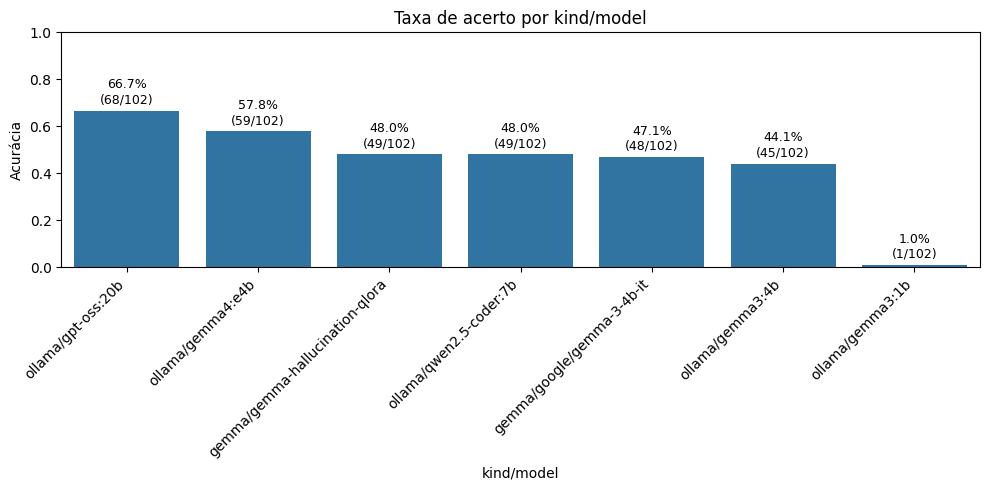

In [5]:
# Gráfico de barras da acurácia (acertos/total) por kind/model
plt.figure(figsize=(max(10, 0.45 * len(summary)), 5))
ax = sns.barplot(data=summary, x="kind_model", y="acuracia", color=sns.color_palette()[0])

ax.set_xlabel("kind/model")
ax.set_ylabel("Acurácia")
ax.set_ylim(0, 1)
ax.set_title("Taxa de acerto por kind/model")
plt.xticks(rotation=45, ha="right")

# Anota: percentual e (acertos/total)
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{a:.1%}\n({c}/{t})" for a, c, t in zip(summary["acuracia"], summary["acertos"], summary["total"])],
        padding=3,
        fontsize=9,
    )

plt.tight_layout()
plt.show()

In [8]:
results_by_sample = {}

base_model = 'gemma/google/gemma-3-4b-it'
qlora_model = 'gemma/gemma-hallucination-qlora'


for result in evaluation_results:
    key = result["sample_index"]
    model_key = model_key = f'{result["kind"]}/{result["model"]}'
    if key not in results_by_sample:
        results_by_sample[key] = {}
    results_by_sample[key][model_key] = result

total_divergences = 0

for sample_index, results in results_by_sample.items():
    try:
        if results[qlora_model]['correct'] != results[base_model]['correct']:
            total_divergences += 1
            # Encontrou um caso onde os modelos discordam
            print(f"Find Divertgence in index: {sample_index}")

            base_model_prediction = results[base_model].get('parsed_response', {}).get('level', 'N/A')
            base_model_explanation = results[base_model].get('parsed_response', {}).get('explanation', 'N/A')
            base_model_correct = "[CORRECT]" if results[base_model].get('correct', 'N/A') else "[WRONG]"
            print(f"Base model prediction {base_model_correct}: {base_model_prediction}")
            print(f"Base model explanation: {base_model_explanation}")
            print("-" * 80)

            qlora_model_prediction = results[qlora_model].get('parsed_response', {}).get('level', 'N/A')
            qlora_model_explanation = results[qlora_model].get('parsed_response', {}).get('explanation', 'N/A')
            qlora_model_correct = "[CORRECT]" if results[qlora_model].get('correct', 'N/A') else "[WRONG]"
            print(f"QLoRA model prediction {qlora_model_correct}: {qlora_model_prediction}")
            print(f"QLoRA model explanation: {qlora_model_explanation}")
            print("=" * 80)

            print()
    except:
        print(f"Missing results for sample index {sample_index}. Skipping.")
        continue
        

Find Divertgence in index: 7
Base model prediction [CORRECT]: correct
Base model explanation: The code correctly calculates the maximum average path cost. It uses dynamic programming to store the maximum cost to reach each cell from the top-left cell. The final result is the maximum cost to reach the bottom-right cell divided by the number of cells in the path, which is the maximum average path cost.
--------------------------------------------------------------------------------
QLoRA model prediction [WRONG]: functional_error
QLoRA model explanation: The candidate function calculates the maximum path sum using dynamic programming, but it then divides by the number of cells in the path (2*n - 1) to compute the average. This is incorrect because the problem asks for the maximum average cost per cell, which requires dividing the total path cost by the number of cells visited *along the optimal path*. The DP table stores the maximum path sum to each cell, and the correct average is dp[n-

In [6]:

total_divergences

17